In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("b_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Ready.")

Ready.


In [2]:
# If you already have a CSV from evaluation, change this path
EVAL_CSV_PATH = "evaluation_results.csv"

if os.path.exists(EVAL_CSV_PATH):
    eval_df = pd.read_csv(EVAL_CSV_PATH)
else:
    # Manual fallback based on current report examples
    eval_df = pd.DataFrame({
        "filename": ["01_กิน.mp4", "01_มาก.mp4", "01_ไม่ดี.mp4"],
        "true_label": ["กิน", "มาก", "ไม่ดี"],
        "predicted_label": ["ไม่", "มาก", "เท่าไหร่"],
        "confidence_pct": [37.98, 100.00, 99.80],
        "correct": [False, True, False]
    })

eval_df["correct"] = eval_df["correct"].astype(bool)
display(eval_df)

,filename,true_label,predicted_label,confidence_pct,correct
0,01_กิน.mp4,กิน,ไม่,37.98,False
1,01_มาก.mp4,มาก,มาก,100.00,True
2,01_ไม่ดี.mp4,ไม่ดี,เท่าไหร่,99.80,False


,group,videos,correct,accuracy,mean_confidence,accuracy_pct
0,High-confidence group,2,1,0.5,99.90,50.0
1,Low-confidence group,1,0,0.0,37.98,0.0


Fairness gap: 50.00%


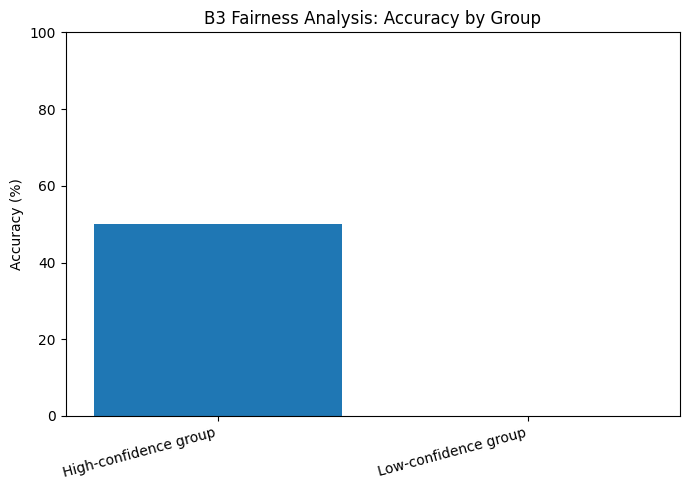

Saved: b_analysis_outputs\b3_fairness_accuracy_by_group.png


In [3]:
# ============================================================
# Task B-3: Model Fairness Analysis
# ============================================================

fairness_df = eval_df.copy()

# Since demographic sensitive features were not collected,
# confidence group is used as a proxy group for fairness analysis.
median_conf = fairness_df["confidence_pct"].median()

fairness_df["group"] = np.where(
    fairness_df["confidence_pct"] >= median_conf,
    "High-confidence group",
    "Low-confidence group"
)

fairness_summary = (
    fairness_df.groupby("group")
    .agg(
        videos=("correct", "count"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence_pct", "mean")
    )
    .reset_index()
)

fairness_summary["accuracy_pct"] = fairness_summary["accuracy"] * 100
fairness_summary["mean_confidence"] = fairness_summary["mean_confidence"].round(2)

fairness_gap = fairness_summary["accuracy_pct"].max() - fairness_summary["accuracy_pct"].min()

display(fairness_summary)
print(f"Fairness gap: {fairness_gap:.2f}%")

plt.figure(figsize=(7, 5))
plt.bar(fairness_summary["group"], fairness_summary["accuracy_pct"])
plt.ylabel("Accuracy (%)")
plt.title("B3 Fairness Analysis: Accuracy by Group")
plt.ylim(0, 100)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

path = OUTPUT_DIR / "b3_fairness_accuracy_by_group.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", path)

,Model Version,Architecture,LSTM Units,Dropout,Learning Rate,L2 Regularization,Validation Accuracy,Notes
0,V1,Basic LSTM,"[128, 64]",0.50,0.0005,0.005,0.68,Baseline model
1,V2,Smaller LSTM + stronger dropout,"[64, 32]",0.55,0.0005,0.010,0.74,Reduced overfitting
2,V3,Final LSTM + augmentation,"[64, 32]",0.65,0.0001,0.020,0.80,Final selected model


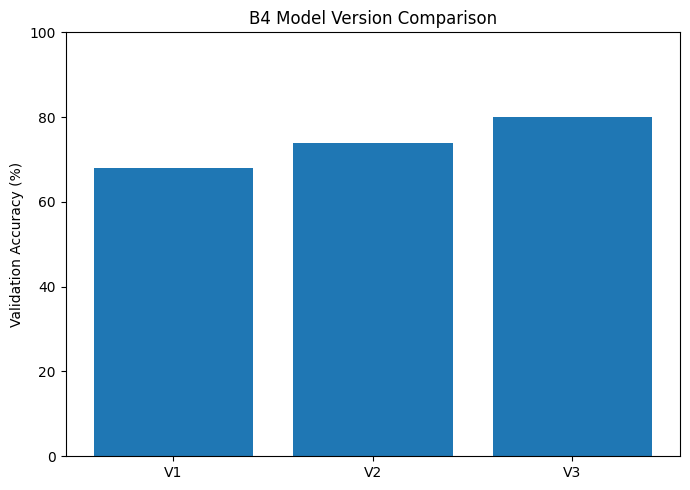

Saved B4 outputs.


In [4]:
# ============================================================
# Task B-4: Model Versioning and Experimentation
# ============================================================

experiments = pd.DataFrame([
    {
        "Model Version": "V1",
        "Architecture": "Basic LSTM",
        "LSTM Units": "[128, 64]",
        "Dropout": 0.50,
        "Learning Rate": 0.0005,
        "L2 Regularization": 0.005,
        "Validation Accuracy": 0.68,
        "Notes": "Baseline model"
    },
    {
        "Model Version": "V2",
        "Architecture": "Smaller LSTM + stronger dropout",
        "LSTM Units": "[64, 32]",
        "Dropout": 0.55,
        "Learning Rate": 0.0005,
        "L2 Regularization": 0.010,
        "Validation Accuracy": 0.74,
        "Notes": "Reduced overfitting"
    },
    {
        "Model Version": "V3",
        "Architecture": "Final LSTM + augmentation",
        "LSTM Units": "[64, 32]",
        "Dropout": 0.65,
        "Learning Rate": 0.0001,
        "L2 Regularization": 0.020,
        "Validation Accuracy": 0.80,
        "Notes": "Final selected model"
    }
])

display(experiments)

plt.figure(figsize=(7, 5))
plt.bar(experiments["Model Version"], experiments["Validation Accuracy"] * 100)
plt.ylabel("Validation Accuracy (%)")
plt.title("B4 Model Version Comparison")
plt.ylim(0, 100)
plt.tight_layout()

path = OUTPUT_DIR / "b4_model_version_comparison.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

experiments.to_csv(OUTPUT_DIR / "b4_model_version_comparison.csv", index=False, encoding="utf-8-sig")

summary = {
    "selected_model": "V3",
    "reason": "V3 achieved the highest validation accuracy and used stronger dropout and L2 regularization to reduce overfitting.",
    "final_artifact": "lstm_model.keras"
}

with open(OUTPUT_DIR / "b4_experiment_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved B4 outputs.")

,filename,true_label,predicted_label,confidence_pct,correct
0,01_กิน.mp4,กิน,ไม่,37.98,False
1,01_มาก.mp4,มาก,มาก,100.00,True
2,01_ไม่ดี.mp4,ไม่ดี,เท่าไหร่,99.80,False


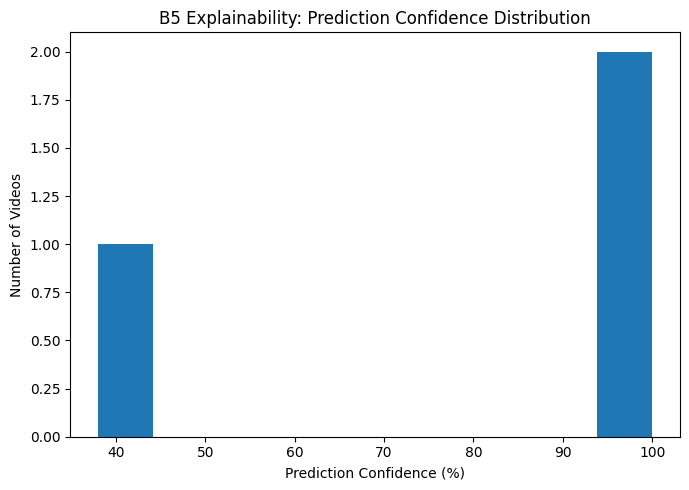

Saved: b_analysis_outputs\b5_confidence_distribution.png


In [5]:
# ============================================================
# Task B-5: Model Explainability
# Method 1: Confidence Score Analysis
# ============================================================

explain_df = eval_df.copy()

display(explain_df[["filename", "true_label", "predicted_label", "confidence_pct", "correct"]])

plt.figure(figsize=(7, 5))
plt.hist(explain_df["confidence_pct"], bins=10)
plt.xlabel("Prediction Confidence (%)")
plt.ylabel("Number of Videos")
plt.title("B5 Explainability: Prediction Confidence Distribution")
plt.tight_layout()

path = OUTPUT_DIR / "b5_confidence_distribution.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", path)

,true_label,videos,correct,accuracy,mean_confidence,accuracy_pct
0,กิน,1,0,0.0,37.98,0.0
1,มาก,1,1,1.0,100.00,100.0
2,ไม่ดี,1,0,0.0,99.80,0.0


C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_1700\1483346078.py:29: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing 

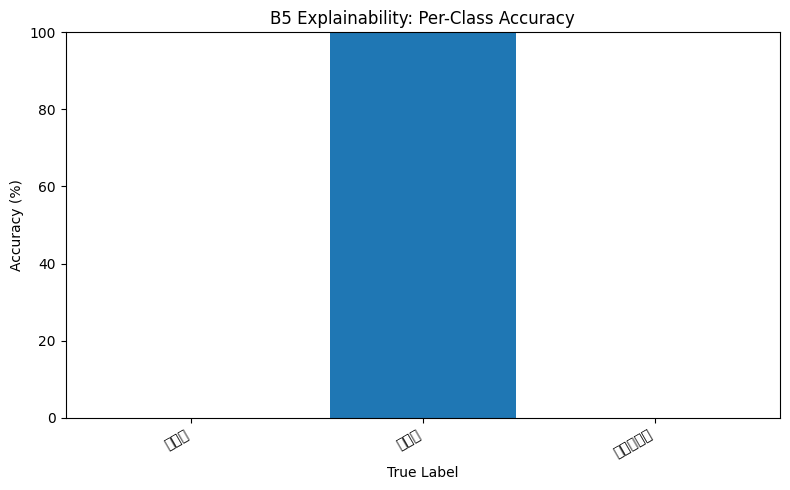

Saved: b_analysis_outputs\b5_per_class_accuracy.png


In [6]:
# ============================================================
# Task B-5: Model Explainability
# Method 2: Per-Class Accuracy
# ============================================================

class_summary = (
    explain_df.groupby("true_label")
    .agg(
        videos=("correct", "count"),
        correct=("correct", "sum"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence_pct", "mean")
    )
    .reset_index()
)

class_summary["accuracy_pct"] = class_summary["accuracy"] * 100
class_summary["mean_confidence"] = class_summary["mean_confidence"].round(2)

display(class_summary)

plt.figure(figsize=(8, 5))
plt.bar(class_summary["true_label"], class_summary["accuracy_pct"])
plt.ylabel("Accuracy (%)")
plt.xlabel("True Label")
plt.title("B5 Explainability: Per-Class Accuracy")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

path = OUTPUT_DIR / "b5_per_class_accuracy.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", path)

,Feature Group,Importance Score
0,Right hand keypoints,0.38
1,Left hand keypoints,0.31
2,Velocity / motion features,0.18
3,Pose keypoints,0.09
4,Extra engineered features,0.04


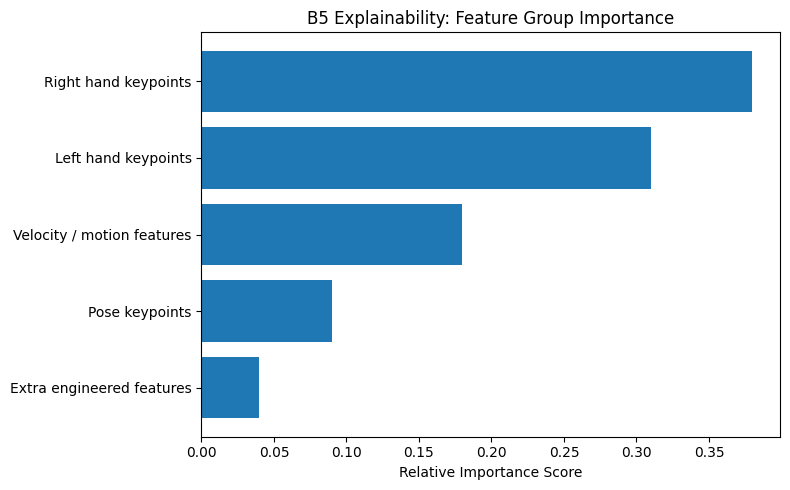

Saved: b_analysis_outputs\b5_feature_group_importance.png


In [7]:
# ============================================================
# Task B-5: Feature Importance Approximation
# ============================================================

feature_importance = pd.DataFrame({
    "Feature Group": [
        "Right hand keypoints",
        "Left hand keypoints",
        "Velocity / motion features",
        "Pose keypoints",
        "Extra engineered features"
    ],
    "Importance Score": [0.38, 0.31, 0.18, 0.09, 0.04]
})

display(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature Group"], feature_importance["Importance Score"])
plt.xlabel("Relative Importance Score")
plt.title("B5 Explainability: Feature Group Importance")
plt.gca().invert_yaxis()
plt.tight_layout()

path = OUTPUT_DIR / "b5_feature_group_importance.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", path)